# Reproduction du modele Quintic SV

Ce notebook suit le papier `The quintic Ornstein-Uhlenbeck volatility model that jointly calibrates SPX & VIX smiles`.

Objectif : reconstruire les courbes du papier avec les parametres publies, puis simuler les donnees de marche manquantes la ou le papier utilisait des donnees CBOE.

## Structure du projet

Le projet est separe en petits modules :

- `quintic_sv/model.py` pour la dynamique de `X_t`.
- `quintic_sv/pricing.py` pour le pricing SPX et VIX.
- `quintic_sv/configs.py` pour les parametres des figures du papier.
- `quintic_sv/market.py` pour simuler un pseudo-marche en absence de donnees reelles.
- `quintic_sv/plots.py` pour tracer les figures.

## Donnees externes manquantes

Le papier a besoin de trois sources externes :

- options SPX par maturite et strike ;
- options VIX par maturite et strike ;
- futures VIX pour la courbe a terme.

Sans ces donnees, on fait deux choses :

- on garde les parametres publies dans le papier pour reproduire les courbes du modele ;
- on simule des bid/ask et une courbe `xi_0` de marche autour des courbes du modele.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'quintic_sv').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from quintic_sv.paper_figures import (
    build_figure_1_bundle,
    build_figure_3_bundle,
    build_figure_4_bundle,
    build_figure_5_bundle,
)
from quintic_sv.plots import plot_forward_curve_comparison, plot_joint_smiles, plot_time_dependent_h

# 1.0 = budget proche du papier ; plus petit = execution plus rapide.
budget_scale = 0.35

## 1. Modele de volatilite

Formule utilisee :

`dS_t / S_t = sigma_t dB_t` avec `sigma_t = sqrt(xi_0(t)) p(X_t) / sqrt(E[p(X_t)^2])` et `p(x) = alpha_0 + alpha_1 x + alpha_3 x^3 + alpha_5 x^5`.

Entrees : `rho`, `H`, `eps`, les coefficients `alpha`, et la courbe `xi_0`.

Sortie : une volatilite instantanee `sigma_t` et donc une dynamique pour `S_t`.

Utilite : c'est le coeur du modele, commun au pricing SPX et VIX.

## 2. Pricing SPX/VIX avec `H` constant et courbe spline

Formules utilisees :

- SPX : Monte Carlo exact sur `X_t` puis turbocharging avec antithetiques et control variate.
- VIX : `VIX_T^2 = (100^2 / Delta) * integral_T^(T+Delta) xi_T(u) du`, qui devient un polynome en `X_T`.

Entrees : les parametres calibres de la Figure 1, plus la courbe `xi_0` spline.

Sorties : smiles SPX, smiles VIX, et courbe de variance forward.

Utilite : reproduire les Figures 1 et 2.

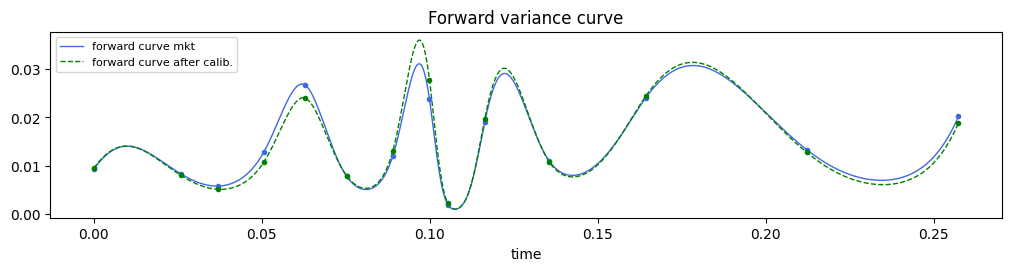

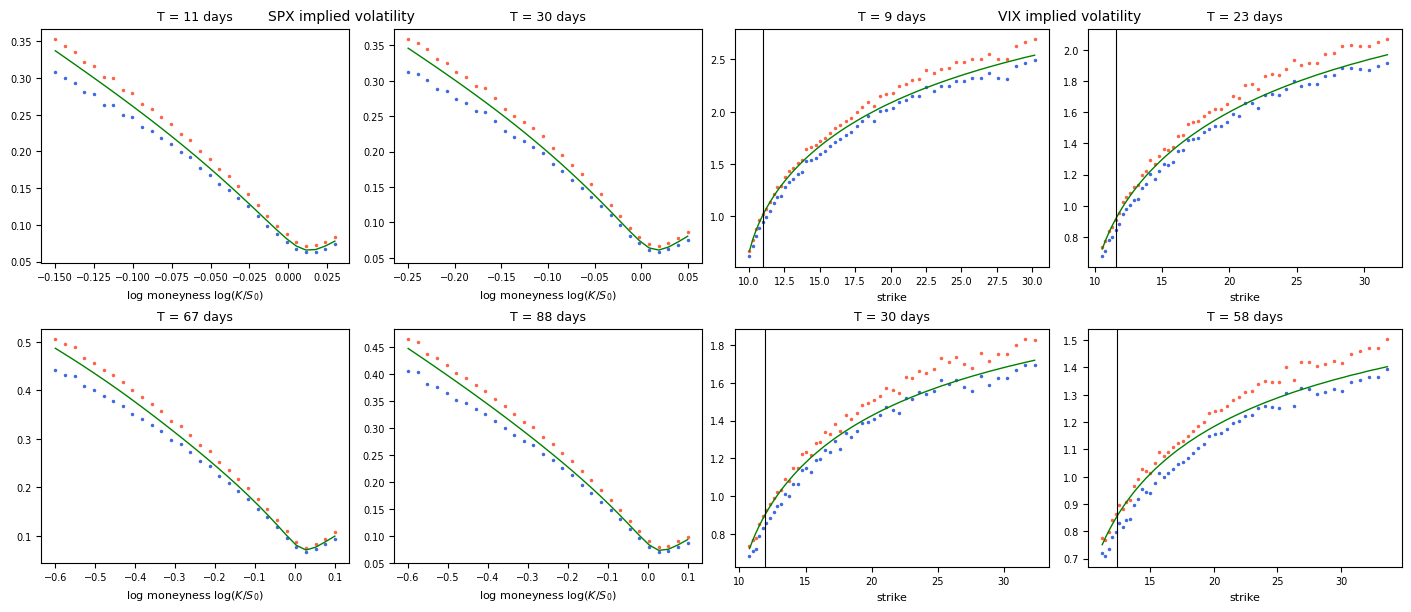

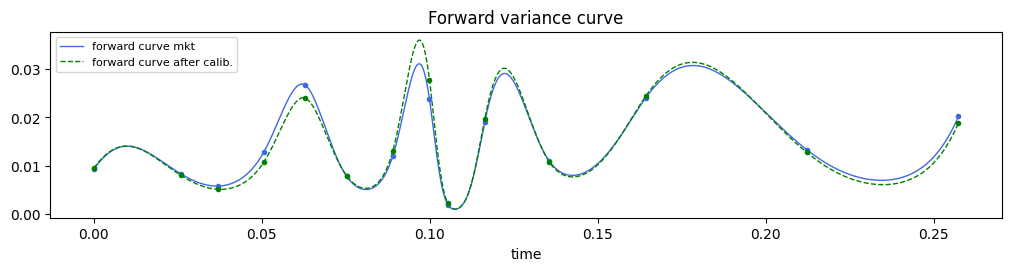

In [2]:
bundle_12 = build_figure_1_bundle(budget_scale=budget_scale)
fig_1 = plot_joint_smiles(bundle_12['spx_smiles'], bundle_12['vix_smiles'], orientation='side_by_side')
fig_2 = plot_forward_curve_comparison(bundle_12['forward_curve'])
fig_1
fig_2

## 3. Courbe de variance parametrique

Formule utilisee : `xi_0(t) = a e^{-b t} + c (1 - e^{-b t})`.

Entrees : `a`, `b`, `c` et les memes parametres du modele pour `X_t`.

Sortie : une courbe `xi_0(t)` plus rigide que la spline, mais simple a calibrer.

Utilite : le papier l'utilise quand on ajuste peu de slices, ici pour les Figures 3 et 4.

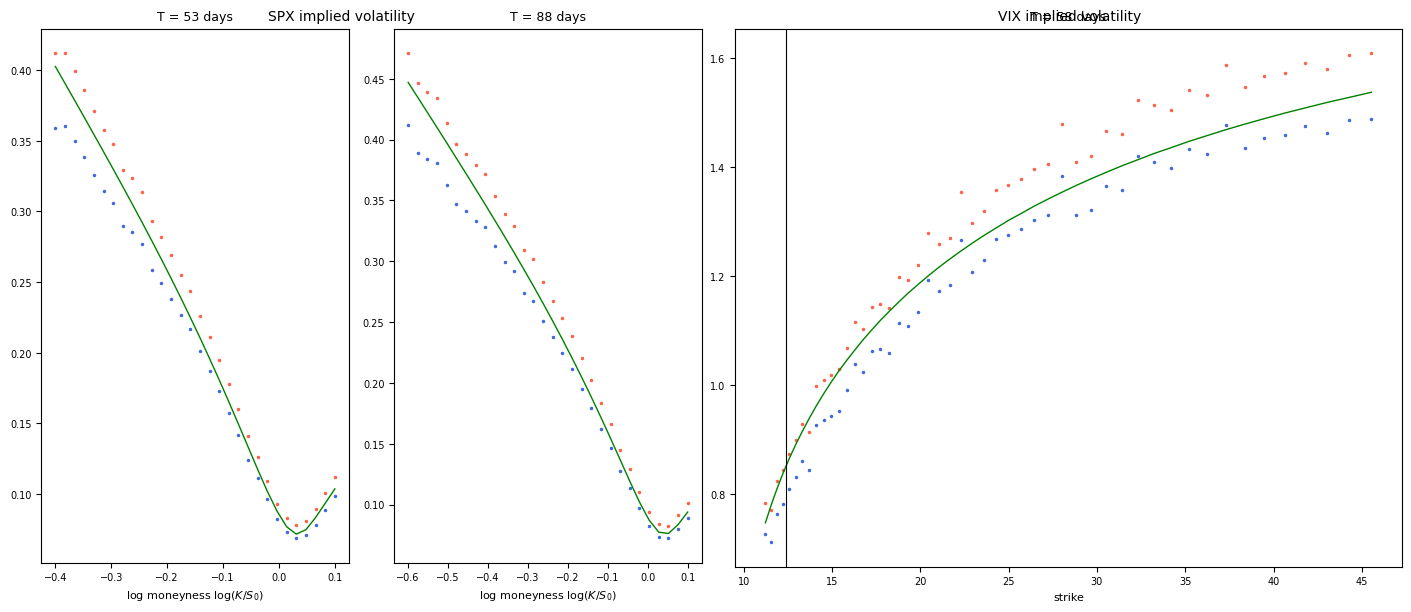

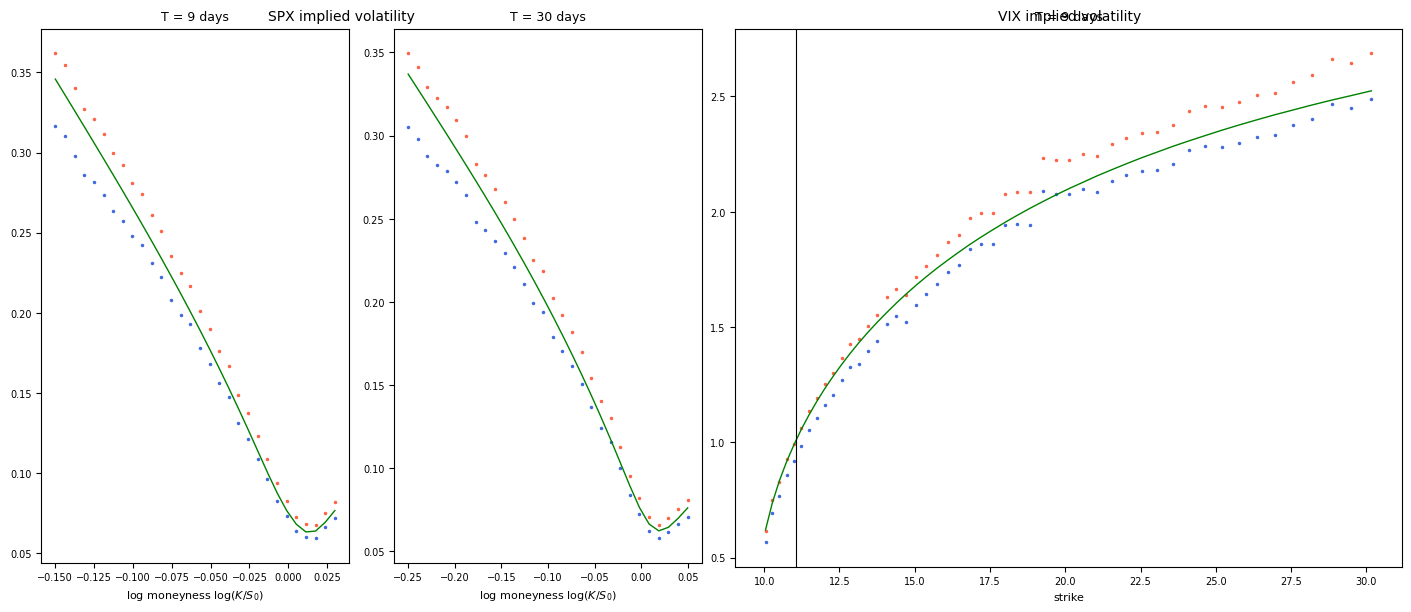

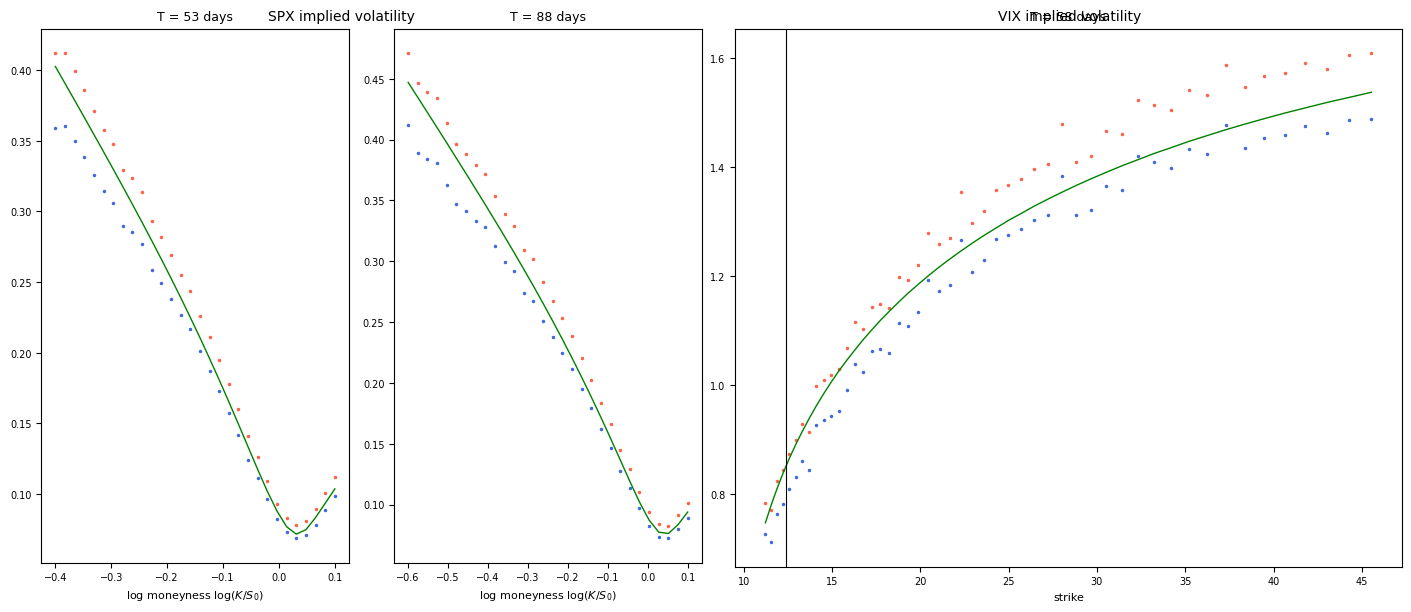

In [3]:
bundle_3 = build_figure_3_bundle(budget_scale=budget_scale)
bundle_4 = build_figure_4_bundle(budget_scale=budget_scale)
fig_3 = plot_joint_smiles(bundle_3['spx_smiles'], bundle_3['vix_smiles'], orientation='side_by_side')
fig_4 = plot_joint_smiles(bundle_4['spx_smiles'], bundle_4['vix_smiles'], orientation='side_by_side')
fig_3
fig_4

## 4. `H(t)` dependant du temps

Formule utilisee : `H(t) = H_0 e^{-kappa t} + H_inf (1 - e^{-kappa t})`.

Entrees : `H_0`, `H_inf`, `kappa`, `eps`, les coefficients `alpha`, et une courbe spline `xi_0`.

Sorties : smiles plus longs en maturite, courbe de variance forward, et courbe `H(t)`.

Utilite : ameliorer les fits au-dela de 3-4 mois, comme dans les Figures 5 a 7.

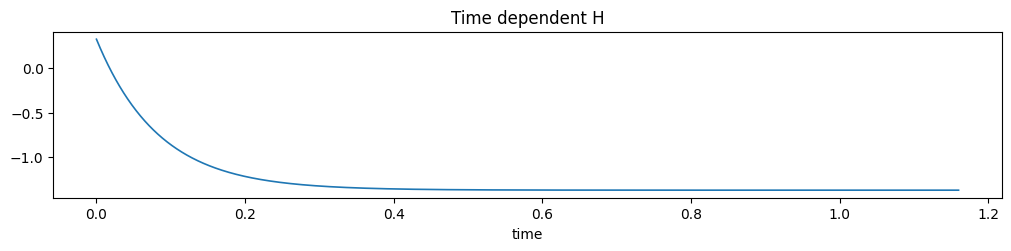

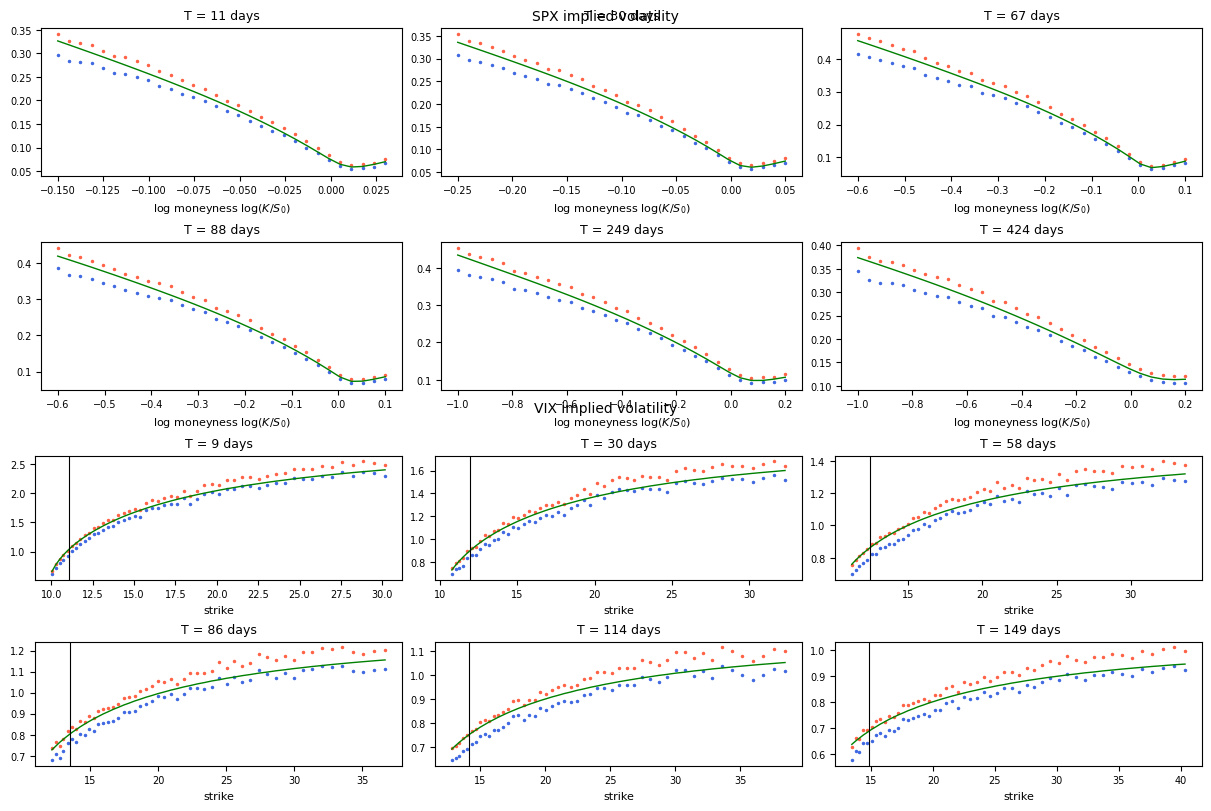

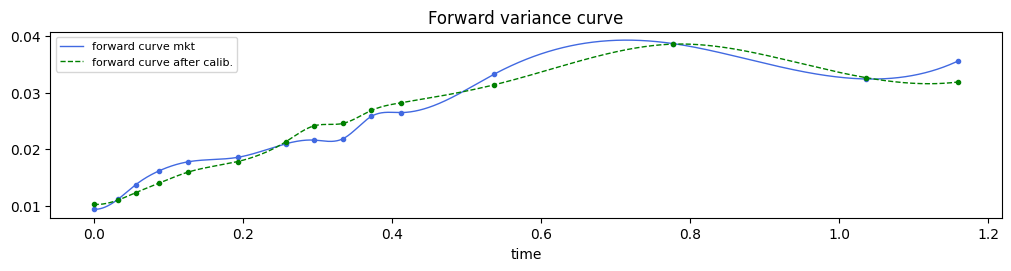

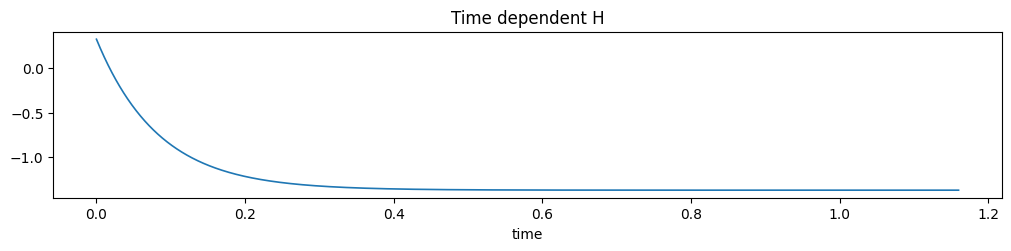

In [4]:
bundle_567 = build_figure_5_bundle(budget_scale=budget_scale)
fig_5 = plot_joint_smiles(bundle_567['spx_smiles'], bundle_567['vix_smiles'], orientation='stacked')
fig_6 = plot_forward_curve_comparison(bundle_567['forward_curve'])
fig_7 = plot_time_dependent_h(bundle_567['h_times'], bundle_567['h_values'])
fig_5
fig_6
fig_7

## 5. Ou brancher de vraies donnees plus tard

Si tu recuperes des donnees CBOE, les points de branchement sont :

- dans `quintic_sv/market.py` pour remplacer les bid/ask simules ;
- dans `quintic_sv/configs.py` pour injecter les vraies maturites et courbes ;
- juste avant la construction de `xi_0`, en remplacant la courbe synthetique par une courbe extraite via Carr-Madan.

Dans cette version, le notebook reste volontairement bref et montre le bon endroit logique pour chaque entree/sortie.